# 02 — Análisis exploratorio de automatización

## Proyecto: HR Process Automation Scanner

El objetivo de este notebook es analizar el ranking final de oportunidades de automatización generado en la fase anterior.

En esta fase se explorarán los patrones principales del dataset final para identificar:

- procesos HR con mayor potencial de automatización;
- sistemas HR con mayor oportunidad de optimización;
- regiones y canales con mayor fricción operativa;
- distribución de prioridades de automatización;
- tipos de soluciones recomendadas;
- oportunidades con mayor ahorro operativo estimado.

Este análisis servirá como base para las visualizaciones, el storytelling ejecutivo, el modelo predictivo y la futura aplicación en Streamlit.

In [36]:
# Importar librerías y rutas:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.max_colwidth", 120)

PROJECT_ROOT = Path.cwd().parent

DATA_PATH = PROJECT_ROOT / "data"
FINAL_DATA_PATH = DATA_PATH / "final"
REPORTS_PATH = PROJECT_ROOT / "reports"

REPORTS_PATH.mkdir(parents=True, exist_ok=True)

print("Ruta final:", FINAL_DATA_PATH)
print("Existe data/final:", FINAL_DATA_PATH.exists())

Ruta final: /Users/gabrielbohorquez/Desktop/Ironhack/PROYECTO_FINAL/HR-Process-Automation-Scanner/data/final
Existe data/final: True


## 2.1 Carga del dataset final

En esta sección se carga el dataset final generado en el notebook anterior.

Este dataset contiene el ranking de oportunidades de automatización por unidad operativa de HR, incluyendo:

- proceso HR;
- sistema HR;
- región;
- canal de contacto;
- volumen de casos;
- score de automatización;
- prioridad de automatización;
- solución recomendada;
- horas operativas estimadas ahorrables.

In [37]:
# Cargar dataset final:
ranking_path = FINAL_DATA_PATH / "hr_process_automation_ranking.csv"

df = pd.read_csv(ranking_path)

df.head()

,process_unit_id_v2,hr_process_name,hr_system_name,region,contact_channel,total_cases,avg_resolution_time_hours,avg_first_response_time_hours,sla_breach_rate,escalation_rate,avg_complexity_score,avg_satisfaction_score,avg_previous_cases,avg_employee_tenure_months,high_priority_rate,urgent_priority_rate,volume_score,resolution_time_score,first_response_score,sla_risk_score,escalation_score,complexity_score,previous_cases_score,high_priority_score,urgent_priority_score,automation_score,automation_priority,recommended_solution,estimated_savings_rate,estimated_hours_saved,estimated_manual_work_rate,estimated_manual_handling_time_hours,estimated_operational_hours_saved,ranking
0,HR System Performance Issue | Payroll Payment Gateway | Europe | Social Media,HR System Performance Issue,Payroll Payment Gateway,Europe,Social Media,89,122.775281,40.720674,0.573034,0.460674,6.168539,2.921348,10.696629,31.359551,0.280899,0.280899,0.912281,0.507705,0.778446,0.635957,0.429538,0.738190,0.669811,0.604577,0.494353,66.45,Alta,Automatización parcial con alertas SLA,0.35,3824.45,0.18,22.10,688.42,1
1,Benefits Cancellation Request | Payroll System | Asia | Social Media,Benefits Cancellation Request,Payroll System,Asia,Social Media,84,121.301310,43.382857,0.571429,0.452381,6.392857,2.809524,10.488095,32.202381,0.309524,0.214286,0.824561,0.483172,0.920397,0.632284,0.411581,0.832642,0.627396,0.678526,0.328817,65.56,Alta,Automatización parcial con alertas SLA,0.35,3566.26,0.18,21.83,641.80,2
2,Benefits Reimbursement Request | Benefits Administration System | Europe | Phone,Benefits Reimbursement Request,Benefits Administration System,Europe,Phone,74,134.088243,43.979054,0.608108,0.567568,5.648649,2.702703,10.270270,30.297297,0.256757,0.229730,0.649123,0.695999,0.952186,0.716207,0.660988,0.519283,0.583091,0.542208,0.367196,65.23,Alta,Automatización parcial con alertas SLA,0.35,3472.89,0.18,24.14,625.23,3
3,Benefits Reimbursement Request | Employee Mobile App | Asia | Email,Benefits Reimbursement Request,Employee Mobile App,Asia,Email,76,140.531842,40.630526,0.526316,0.565789,6.065789,3.197368,10.355263,32.605263,0.236842,0.236842,0.684211,0.803246,0.773639,0.529065,0.657138,0.694925,0.600378,0.490760,0.384871,64.50,Alta,Automatización parcial con alertas SLA,0.35,3738.15,0.18,25.30,672.98,4
4,Payroll Support Request | Payroll Payment Gateway | Asia | Chat,Payroll Support Request,Payroll Payment Gateway,Asia,Chat,82,121.986220,39.002317,0.512195,0.634146,5.951220,2.707317,11.243902,30.256098,0.243902,0.329268,0.789474,0.494572,0.686821,0.496757,0.805147,0.646684,0.781125,0.509000,0.614553,64.38,Alta,Chatbot o asistente virtual,0.35,3501.00,0.18,21.96,630.25,5


In [38]:
# Revisar dimensiones y columnas:
print("Filas:", df.shape[0])
print("Columnas:", df.shape[1])

df.columns.tolist()

Filas: 3000
Columnas: 34


['process_unit_id_v2',
 'hr_process_name',
 'hr_system_name',
 'region',
 'contact_channel',
 'total_cases',
 'avg_resolution_time_hours',
 'avg_first_response_time_hours',
 'sla_breach_rate',
 'escalation_rate',
 'avg_complexity_score',
 'avg_satisfaction_score',
 'avg_previous_cases',
 'avg_employee_tenure_months',
 'high_priority_rate',
 'urgent_priority_rate',
 'volume_score',
 'resolution_time_score',
 'first_response_score',
 'sla_risk_score',
 'escalation_score',
 'complexity_score',
 'previous_cases_score',
 'high_priority_score',
 'urgent_priority_score',
 'automation_score',
 'automation_priority',
 'recommended_solution',
 'estimated_savings_rate',
 'estimated_hours_saved',
 'estimated_manual_work_rate',
 'estimated_manual_handling_time_hours',
 'estimated_operational_hours_saved',
 'ranking']

In [39]:
# Revisar tipos de datos:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 34 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   process_unit_id_v2                    3000 non-null   object 
 1   hr_process_name                       3000 non-null   object 
 2   hr_system_name                        3000 non-null   object 
 3   region                                3000 non-null   object 
 4   contact_channel                       3000 non-null   object 
 5   total_cases                           3000 non-null   int64  
 6   avg_resolution_time_hours             3000 non-null   float64
 7   avg_first_response_time_hours         3000 non-null   float64
 8   sla_breach_rate                       3000 non-null   float64
 9   escalation_rate                       3000 non-null   float64
 10  avg_complexity_score                  3000 non-null   float64
 11  avg_satisfaction_

In [40]:
# Revisar valores nulos:
missing_summary = (
    df
    .isna()
    .sum()
    .reset_index()
    .rename(columns={"index": "columna", 0: "valores_nulos"})
)

missing_summary["porcentaje_nulos"] = (
    missing_summary["valores_nulos"] / len(df) * 100
).round(2)

missing_summary.sort_values("porcentaje_nulos", ascending=False)

,columna,valores_nulos,porcentaje_nulos
0,process_unit_id_v2,0,0.0
25,automation_score,0,0.0
19,sla_risk_score,0,0.0
20,escalation_score,0,0.0
21,complexity_score,0,0.0
22,previous_cases_score,0,0.0
23,high_priority_score,0,0.0
24,urgent_priority_score,0,0.0
26,automation_priority,0,0.0
1,hr_process_name,0,0.0


In [41]:
# Resumen estadístico general:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
total_cases,3000.0,66.666667,8.154041,37.000000,61.000000,66.500000,72.000000,94.000000
avg_resolution_time_hours,3000.0,120.522121,8.656218,92.271563,114.595877,120.374598,126.463254,152.353115
avg_first_response_time_hours,3000.0,36.305755,2.577500,26.121471,34.487752,36.280371,38.025059,44.875763
sla_breach_rate,3000.0,0.500401,0.061328,0.295082,0.457143,0.500000,0.541667,0.732143
escalation_rate,3000.0,0.501977,0.062786,0.262295,0.459016,0.500000,0.545455,0.724138
avg_complexity_score,3000.0,5.500199,0.352114,4.415385,5.259259,5.509619,5.743330,6.790323
avg_satisfaction_score,3000.0,3.001225,0.174992,2.460317,2.880597,3.000000,3.119403,3.702128
avg_previous_cases,3000.0,9.995856,0.742101,7.403509,9.492480,10.015268,10.483594,12.320000
avg_employee_tenure_months,3000.0,30.381641,2.137890,20.812500,28.939394,30.437500,31.805389,38.709677
high_priority_rate,3000.0,0.251188,0.053019,0.046875,0.214286,0.250000,0.285714,0.433962


## 2.2 Ajuste de canales internos HR

El dataset original provenía de un contexto de atención al cliente. Por ese motivo, incluía canales como "Social Media", que no son adecuados para interpretar procesos internos de HR Operations.

Para adaptar el análisis al contexto de People Operations, se reinterpretarán los canales originales como canales internos de servicio al empleado.

La transformación será:

- Email → Email
- Chat → HR Chat / Virtual Assistant
- Phone → Phone
- Web Form → Employee Self-Service Portal
- Social Media → Internal Collaboration Tool

Este ajuste permite que los análisis posteriores sean coherentes con un entorno realista de HR Operations.

In [42]:
hr_channel_mapping = {
    "Email": "Email",
    "Chat": "HR Chat / Virtual Assistant",
    "Phone": "Phone",
    "Web Form": "Employee Self-Service Portal",
    "Social Media": "Internal Collaboration Tool"
}

df["hr_contact_channel"] = df["contact_channel"].map(hr_channel_mapping)

df[["contact_channel", "hr_contact_channel"]].drop_duplicates().sort_values("contact_channel")

,contact_channel,hr_contact_channel
4,Chat,HR Chat / Virtual Assistant
3,Email,Email
2,Phone,Phone
0,Social Media,Internal Collaboration Tool
19,Web Form,Employee Self-Service Portal


In [43]:
unmapped_channels = df[df["hr_contact_channel"].isna()]["contact_channel"].unique()

print("Canales sin mapear:")
print(unmapped_channels)

Canales sin mapear:
[]


### Interpretación del ajuste de canales

No se encontraron canales sin mapear, por lo que todos los valores originales fueron transformados correctamente.

A partir de este punto, el análisis utilizará `hr_contact_channel` como canal interno HR, en lugar de la columna original `contact_channel`.

Esto mejora la coherencia del proyecto y evita presentar canales propios de atención al cliente como si fueran canales reales de HR Operations.

## 2.3 Distribución de prioridad de automatización

El primer análisis consiste en revisar cuántas unidades operativas fueron clasificadas como prioridad alta, media o baja.

Esto permite entender cómo se distribuye el potencial de automatización dentro del conjunto de procesos analizados.

In [44]:
priority_distribution = (
    df["automation_priority"]
    .value_counts()
    .reset_index()
)

priority_distribution.columns = ["automation_priority", "total_units"]

priority_distribution

,automation_priority,total_units
0,Media,1497
1,Alta,753
2,Baja,750


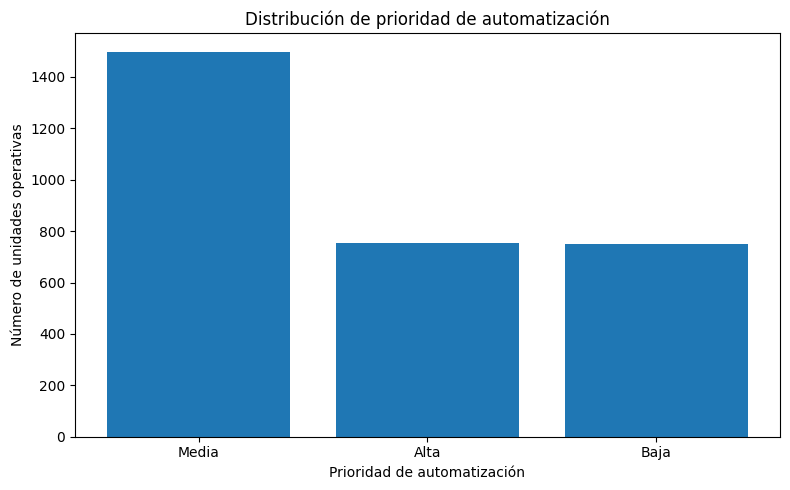

In [45]:
plt.figure(figsize=(8, 5))
plt.bar(
    priority_distribution["automation_priority"],
    priority_distribution["total_units"]
)

plt.title("Distribución de prioridad de automatización")
plt.xlabel("Prioridad de automatización")
plt.ylabel("Número de unidades operativas")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Interpretación

La distribución de prioridad muestra una segmentación equilibrada de las unidades operativas analizadas.

La clasificación permite separar las oportunidades en tres grupos:

- prioridad alta: mejores candidatos relativos para automatización;
- prioridad media: oportunidades con potencial, pero no necesariamente inmediatas;
- prioridad baja: unidades con menor prioridad de intervención.

Esta segmentación es útil para priorizar iniciativas de automatización de forma más ordenada.

## 2.4 Top 10 oportunidades de automatización

Este análisis muestra las unidades operativas con mayor Automation Opportunity Score.

Estas unidades representan los mejores candidatos relativos para iniciativas de automatización u optimización con IA.

In [46]:
top_10_opportunities = df[[
    "ranking",
    "hr_process_name",
    "hr_system_name",
    "region",
    "hr_contact_channel",
    "total_cases",
    "automation_score",
    "automation_priority",
    "recommended_solution",
    "estimated_operational_hours_saved"
]].head(10)

top_10_opportunities

,ranking,hr_process_name,hr_system_name,region,hr_contact_channel,total_cases,automation_score,automation_priority,recommended_solution,estimated_operational_hours_saved
0,1,HR System Performance Issue,Payroll Payment Gateway,Europe,Internal Collaboration Tool,89,66.45,Alta,Automatización parcial con alertas SLA,688.42
1,2,Benefits Cancellation Request,Payroll System,Asia,Internal Collaboration Tool,84,65.56,Alta,Automatización parcial con alertas SLA,641.80
2,3,Benefits Reimbursement Request,Benefits Administration System,Europe,Phone,74,65.23,Alta,Automatización parcial con alertas SLA,625.23
3,4,Benefits Reimbursement Request,Employee Mobile App,Asia,Email,76,64.50,Alta,Automatización parcial con alertas SLA,672.98
4,5,Payroll Support Request,Payroll Payment Gateway,Asia,HR Chat / Virtual Assistant,82,64.38,Alta,Chatbot o asistente virtual,630.25
5,6,HR System Performance Issue,HR Case Management Platform,Africa,Internal Collaboration Tool,75,64.38,Alta,Automatización parcial con alertas SLA,627.64
6,7,HR Platform Bug Report,HR Case Management Platform,Australia,Phone,71,63.87,Alta,Automatización parcial con alertas SLA,576.52
7,8,Benefits Reimbursement Request,Employee Self-Service Portal,Europe,Phone,72,63.73,Alta,Automatización parcial con alertas SLA,565.99
8,9,HR Platform Bug Report,Payroll Payment Gateway,Europe,Phone,74,63.42,Alta,Automatización parcial con alertas SLA,602.43
9,10,HR System Enhancement Request,HR Case Management Platform,Africa,HR Chat / Virtual Assistant,85,63.37,Alta,Chatbot o asistente virtual,678.30


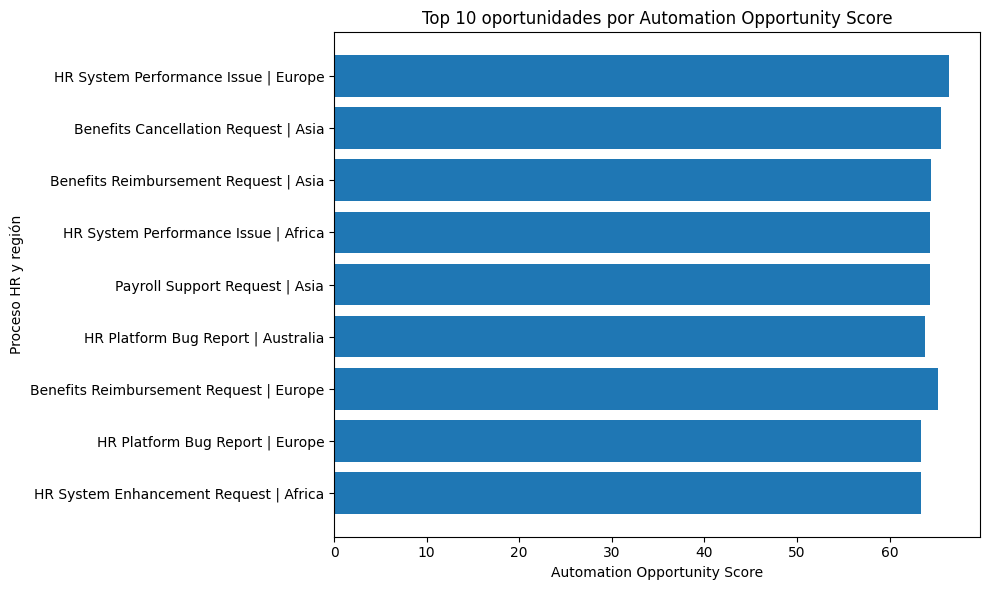

In [47]:
top_10_plot = top_10_opportunities.sort_values("automation_score", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(
    top_10_plot["hr_process_name"] + " | " + top_10_plot["region"],
    top_10_plot["automation_score"]
)

plt.title("Top 10 oportunidades por Automation Opportunity Score")
plt.xlabel("Automation Opportunity Score")
plt.ylabel("Proceso HR y región")
plt.tight_layout()
plt.show()

### Interpretación

El ranking muestra que las mejores oportunidades no dependen únicamente del proceso HR general.

Las unidades mejor posicionadas combinan proceso, sistema, región y canal interno. Esto confirma que la automatización debe analizarse a nivel operativo granular, no solo a nivel de proceso amplio.

El recomendador permite identificar oportunidades concretas donde una intervención tecnológica podría tener mayor impacto.

## 2.5 Procesos HR con mayor score promedio

Este análisis permite identificar qué procesos de HR Operations presentan mayor potencial promedio de automatización.

In [48]:
process_score_summary = (
    df
    .groupby("hr_process_name")
    .agg(
        total_units=("process_unit_id_v2", "count"),
        total_cases=("total_cases", "sum"),
        avg_automation_score=("automation_score", "mean"),
        total_estimated_hours_saved=("estimated_operational_hours_saved", "sum")
    )
    .reset_index()
    .sort_values("avg_automation_score", ascending=False)
)

process_score_summary

,hr_process_name,total_units,total_cases,avg_automation_score,total_estimated_hours_saved
6,HR System Performance Issue,300,20074,49.929567,74549.17
8,HRIS Login Issue,300,20002,49.639267,75535.59
5,HR System Enhancement Request,300,20169,49.536467,74397.94
9,Payroll Support Request,300,19997,49.453033,76205.26
1,Benefits Reimbursement Request,300,19900,49.431467,71261.27
0,Benefits Cancellation Request,300,20096,49.387700,73363.64
3,Employee Data Update,300,19877,49.332067,74234.04
4,HR Platform Bug Report,300,19981,49.310133,72874.51
2,Compliance & Access Security Review,300,20040,49.297633,73895.56
7,HRIS Access Suspension,300,19864,49.087767,73054.92


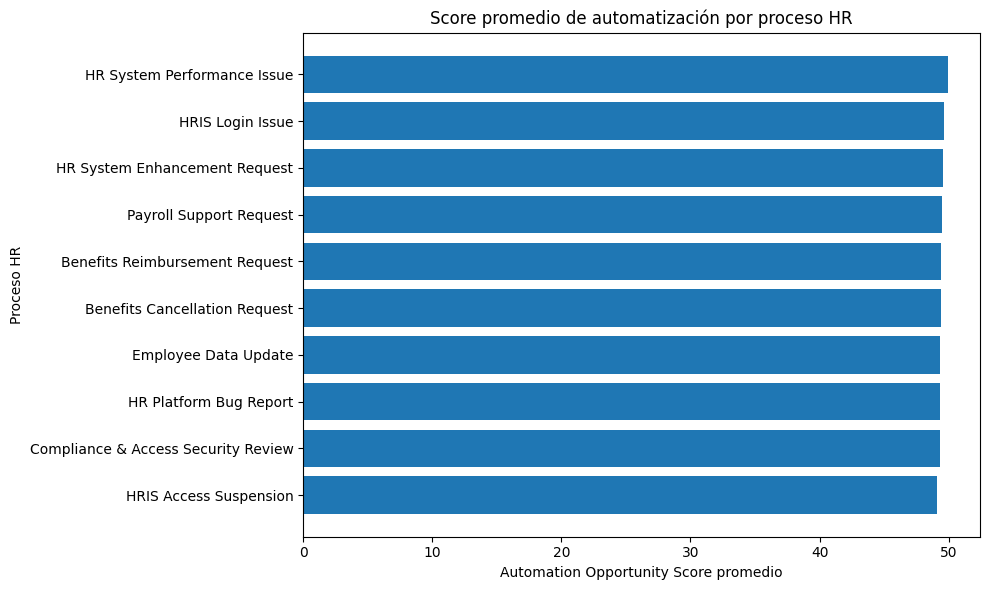

In [49]:
process_score_plot = process_score_summary.sort_values("avg_automation_score", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(
    process_score_plot["hr_process_name"],
    process_score_plot["avg_automation_score"]
)

plt.title("Score promedio de automatización por proceso HR")
plt.xlabel("Automation Opportunity Score promedio")
plt.ylabel("Proceso HR")
plt.tight_layout()
plt.show()

### Interpretación

Los scores promedio por proceso son relativamente similares. Esto indica que el potencial de automatización no depende únicamente del proceso HR general.

La diferencia real aparece al analizar combinaciones específicas de:

- proceso HR;
- sistema HR;
- región;
- canal interno.

Por este motivo, el valor principal del recomendador está en identificar unidades operativas concretas, no solo procesos generales.

## 2.6 Procesos con mayor ahorro operativo estimado

Este análisis identifica los procesos donde la automatización podría liberar más horas operativas estimadas.

El objetivo es priorizar procesos no solo por score, sino también por impacto operativo potencial.

In [50]:
process_savings_summary = (
    df
    .groupby("hr_process_name")
    .agg(
        total_cases=("total_cases", "sum"),
        total_estimated_hours_saved=("estimated_operational_hours_saved", "sum"),
        avg_automation_score=("automation_score", "mean")
    )
    .reset_index()
    .sort_values("total_estimated_hours_saved", ascending=False)
)

process_savings_summary

,hr_process_name,total_cases,total_estimated_hours_saved,avg_automation_score
9,Payroll Support Request,19997,76205.26,49.453033
8,HRIS Login Issue,20002,75535.59,49.639267
6,HR System Performance Issue,20074,74549.17,49.929567
5,HR System Enhancement Request,20169,74397.94,49.536467
3,Employee Data Update,19877,74234.04,49.332067
2,Compliance & Access Security Review,20040,73895.56,49.297633
0,Benefits Cancellation Request,20096,73363.64,49.387700
7,HRIS Access Suspension,19864,73054.92,49.087767
4,HR Platform Bug Report,19981,72874.51,49.310133
1,Benefits Reimbursement Request,19900,71261.27,49.431467


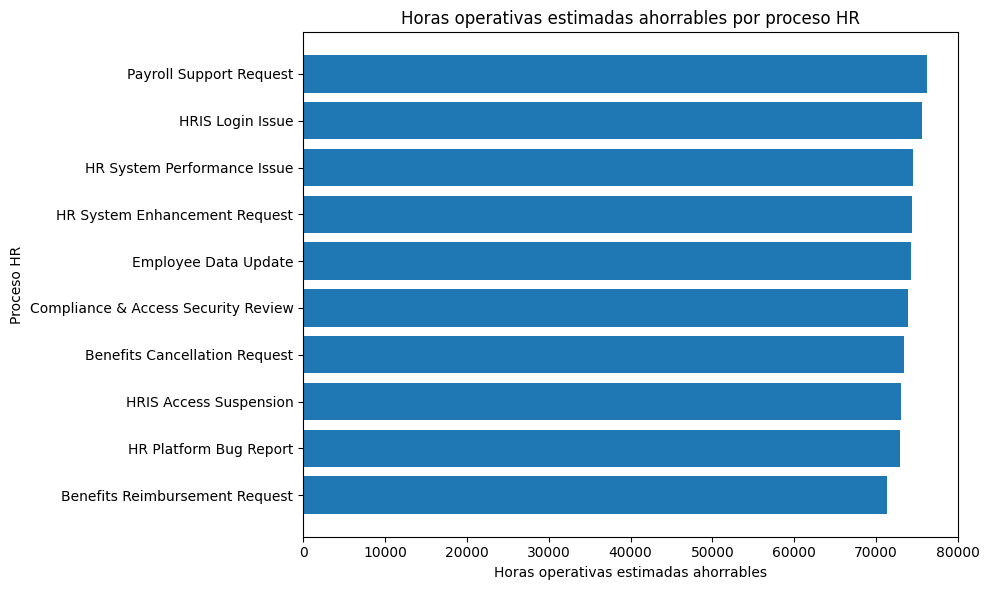

In [51]:
process_savings_plot = process_savings_summary.sort_values("total_estimated_hours_saved", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(
    process_savings_plot["hr_process_name"],
    process_savings_plot["total_estimated_hours_saved"]
)

plt.title("Horas operativas estimadas ahorrables por proceso HR")
plt.xlabel("Horas operativas estimadas ahorrables")
plt.ylabel("Proceso HR")
plt.tight_layout()
plt.show()

### Interpretación

El análisis de ahorro operativo estimado permite identificar dónde una iniciativa de automatización podría liberar mayor capacidad operativa.

Este enfoque complementa el Automation Opportunity Score, ya que una unidad puede tener buen score, pero menor impacto absoluto si su volumen o tiempo operativo estimado es bajo.

Por tanto, la priorización final debe considerar tanto el score como el ahorro operativo estimado.

## 2.7 Sistemas HR con mayor potencial de automatización

Este análisis permite identificar qué plataformas o sistemas HR concentran más oportunidades de automatización.

Esto es útil para priorizar iniciativas tecnológicas, integraciones, mejoras de workflow o automatizaciones dentro del ecosistema HRIS.

In [52]:
system_score_summary = (
    df
    .groupby("hr_system_name")
    .agg(
        total_units=("process_unit_id_v2", "count"),
        total_cases=("total_cases", "sum"),
        avg_automation_score=("automation_score", "mean"),
        total_estimated_hours_saved=("estimated_operational_hours_saved", "sum")
    )
    .reset_index()
    .sort_values("total_estimated_hours_saved", ascending=False)
)

system_score_summary

,hr_system_name,total_units,total_cases,avg_automation_score,total_estimated_hours_saved
5,HR Document Management System,300,20056,49.655833,79613.93
8,Payroll System,300,20111,49.614333,77426.33
2,Employee Mobile App,300,20043,49.933300,76694.45
1,Benefits Portal,300,20095,49.711333,76517.39
7,Payroll Payment Gateway,300,19952,49.228833,72537.43
4,HR Case Management Platform,300,20097,49.408833,72259.46
0,Benefits Administration System,300,19883,49.319933,71567.15
6,HRIS Integration API,300,19835,49.181200,71282.50
3,Employee Self-Service Portal,300,19954,49.230300,71232.68
9,People Analytics Dashboard,300,19974,49.121200,70240.58


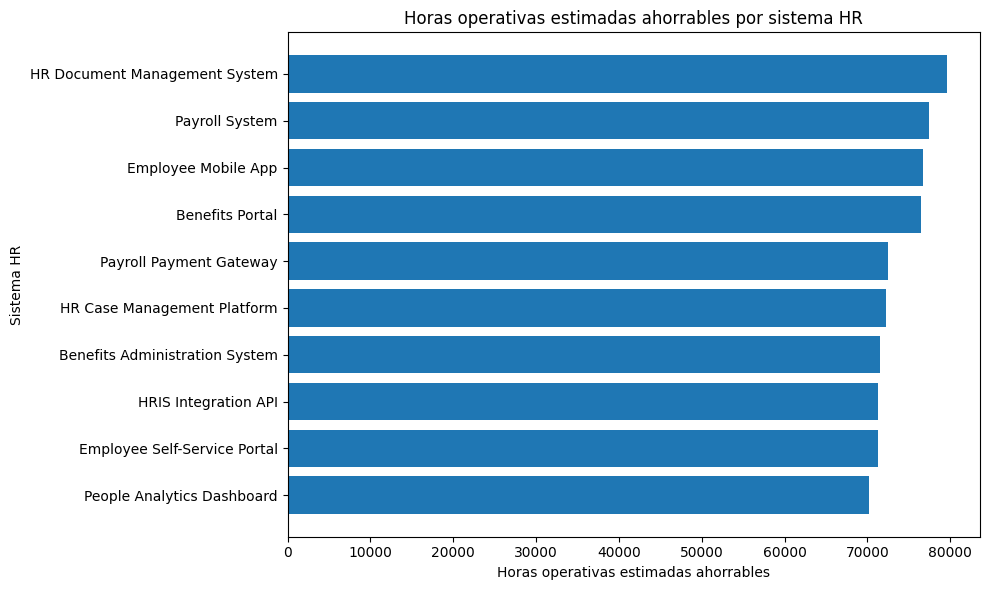

In [53]:
system_plot = system_score_summary.sort_values("total_estimated_hours_saved", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(
    system_plot["hr_system_name"],
    system_plot["total_estimated_hours_saved"]
)

plt.title("Horas operativas estimadas ahorrables por sistema HR")
plt.xlabel("Horas operativas estimadas ahorrables")
plt.ylabel("Sistema HR")
plt.tight_layout()
plt.show()

### Interpretación

El análisis por sistema permite identificar qué plataformas concentran mayor potencial de ahorro operativo.

Esta lectura es útil para priorizar mejoras tecnológicas, automatización de workflows, integración de sistemas o rediseño de procesos dentro del ecosistema HR.

Desde una perspectiva de transformación digital, este análisis ayuda a decidir dónde intervenir primero dentro del stack tecnológico de HR.

## 2.8 Regiones con mayor oportunidad de automatización

Este análisis permite identificar en qué regiones se concentra mayor potencial de ahorro operativo.

La lectura regional ayuda a priorizar iniciativas de automatización por mercado, geografía o centro de servicios.

In [54]:
region_summary = (
    df
    .groupby("region")
    .agg(
        total_units=("process_unit_id_v2", "count"),
        total_cases=("total_cases", "sum"),
        avg_automation_score=("automation_score", "mean"),
        total_estimated_hours_saved=("estimated_operational_hours_saved", "sum")
    )
    .reset_index()
    .sort_values("total_estimated_hours_saved", ascending=False)
)

region_summary

,region,total_units,total_cases,avg_automation_score,total_estimated_hours_saved
5,South America,500,33369,49.56952,124404.64
0,Africa,500,33576,49.59912,123760.20
3,Europe,500,33277,49.31710,123737.28
2,Australia,500,33047,49.37706,123014.91
1,Asia,500,33554,49.52160,122302.56
4,North America,500,33177,49.25866,122152.31


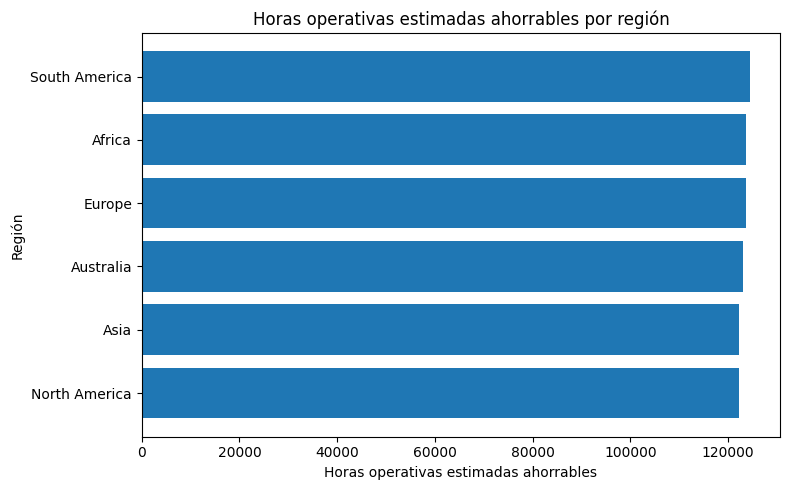

In [55]:
region_plot = region_summary.sort_values("total_estimated_hours_saved", ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(
    region_plot["region"],
    region_plot["total_estimated_hours_saved"]
)

plt.title("Horas operativas estimadas ahorrables por región")
plt.xlabel("Horas operativas estimadas ahorrables")
plt.ylabel("Región")
plt.tight_layout()
plt.show()

### Interpretación

El análisis regional permite observar dónde se concentra el mayor potencial de optimización operativa.

Esta lectura es útil para diseñar una estrategia de despliegue gradual, empezando por las regiones con mayor volumen, mayor fricción o mayor ahorro operativo estimado.

En un contexto real de HR Operations, esta información podría apoyar decisiones sobre priorización regional, asignación de recursos o implementación progresiva de automatizaciones.

## 2.9 Canales internos con mayor fricción operativa

Este análisis evalúa qué canales internos concentran mayor oportunidad de automatización.

Los canales como email, chat interno, portal de autoservicio o herramientas colaborativas pueden requerir soluciones distintas:

- workflows;
- chatbots;
- asistentes virtuales;
- reglas de enrutamiento;
- automatización parcial;
- alertas SLA.

In [56]:
channel_summary = (
    df
    .groupby("hr_contact_channel")
    .agg(
        total_units=("process_unit_id_v2", "count"),
        total_cases=("total_cases", "sum"),
        avg_automation_score=("automation_score", "mean"),
        total_estimated_hours_saved=("estimated_operational_hours_saved", "sum")
    )
    .reset_index()
    .sort_values("total_estimated_hours_saved", ascending=False)
)

channel_summary

,hr_contact_channel,total_units,total_cases,avg_automation_score,total_estimated_hours_saved
3,Internal Collaboration Tool,600,40038,49.728567,150921.26
2,HR Chat / Virtual Assistant,600,40073,49.474700,150120.93
4,Phone,600,40073,49.494433,148623.84
1,Employee Self-Service Portal,600,40090,49.291983,145796.83
0,Email,600,39726,49.212867,143909.04


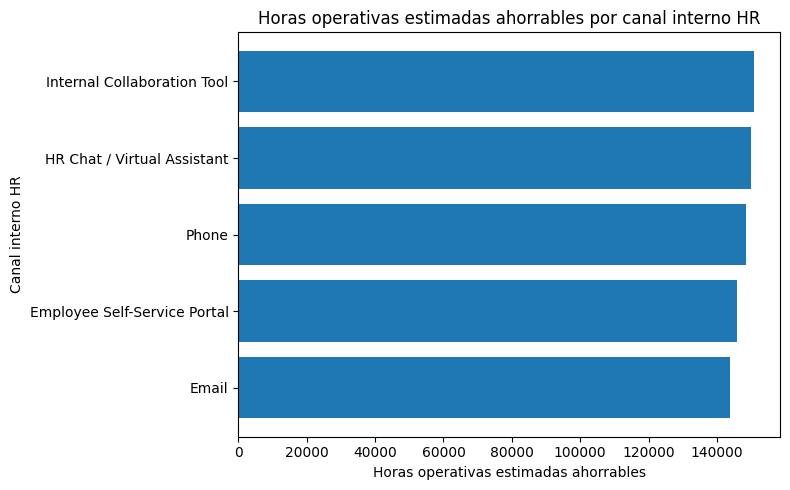

In [57]:
channel_plot = channel_summary.sort_values("total_estimated_hours_saved", ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(
    channel_plot["hr_contact_channel"],
    channel_plot["total_estimated_hours_saved"]
)

plt.title("Horas operativas estimadas ahorrables por canal interno HR")
plt.xlabel("Horas operativas estimadas ahorrables")
plt.ylabel("Canal interno HR")
plt.tight_layout()
plt.show()

### Interpretación

El análisis por canal interno permite identificar dónde se concentra mayor fricción operativa en la entrada y gestión de solicitudes HR.

Este análisis es especialmente útil porque diferentes canales requieren diferentes tipos de intervención:

- los portales de autoservicio pueden mejorarse con workflows y formularios inteligentes;
- los chats internos pueden apoyarse con asistentes virtuales;
- el email puede requerir clasificación automática, reglas de enrutamiento o extracción de información;
- las herramientas colaborativas internas pueden requerir integración con sistemas HRIS o automatización de seguimiento.

Por tanto, el canal no solo describe cómo entra el caso, sino también qué tipo de solución tecnológica puede ser más adecuada.

## 2.10 Distribución de soluciones recomendadas

Este análisis muestra qué tipos de soluciones de automatización aparecen con mayor frecuencia.

El objetivo es entender si las oportunidades detectadas se orientan más hacia workflows, chatbots, alertas SLA, rediseño de procesos o revisión humana asistida.

In [58]:
solution_summary = (
    df
    .groupby("recommended_solution")
    .agg(
        total_units=("process_unit_id_v2", "count"),
        total_cases=("total_cases", "sum"),
        avg_automation_score=("automation_score", "mean"),
        total_estimated_hours_saved=("estimated_operational_hours_saved", "sum")
    )
    .reset_index()
    .sort_values("total_estimated_hours_saved", ascending=False)
)

solution_summary

,recommended_solution,total_units,total_cases,avg_automation_score,total_estimated_hours_saved
1,Automatización parcial con alertas SLA,900,59818,51.103444,234092.37
4,Chatbot o asistente virtual,269,19583,55.611859,154261.36
6,Workflow automation,243,17786,55.498519,140023.76
0,Automatización parcial,685,46852,49.202102,136934.08
2,Automatización prioritaria,62,4613,55.249839,36594.94
3,Baja prioridad de automatización,750,45605,42.964253,21032.25
5,Rediseño del proceso antes de automatizar,91,5743,49.786593,16433.14


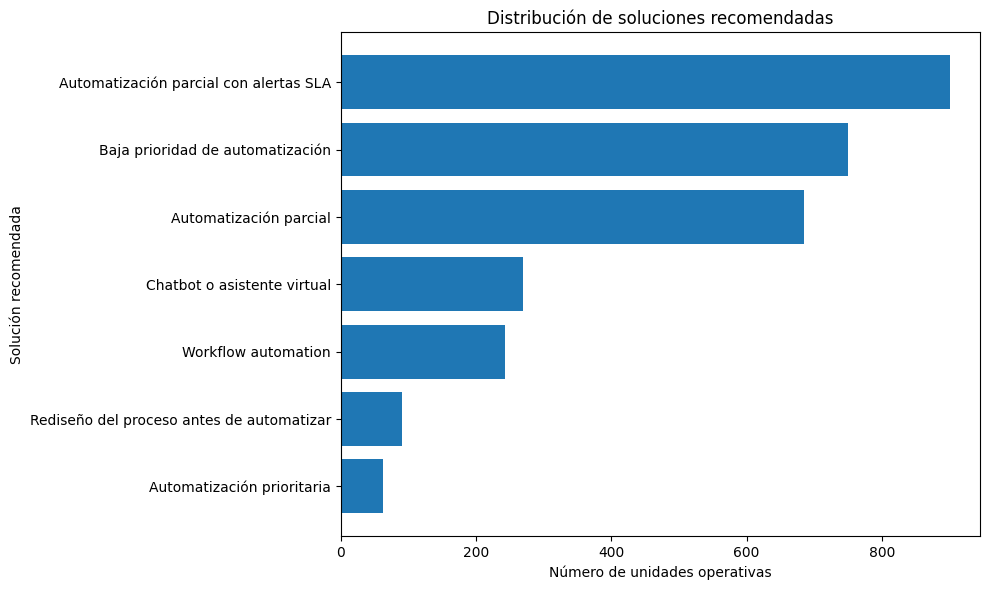

In [59]:
solution_plot = solution_summary.sort_values("total_units", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(
    solution_plot["recommended_solution"],
    solution_plot["total_units"]
)

plt.title("Distribución de soluciones recomendadas")
plt.xlabel("Número de unidades operativas")
plt.ylabel("Solución recomendada")
plt.tight_layout()
plt.show()

### Interpretación

La distribución de soluciones recomendadas traduce el análisis en acciones concretas.

En lugar de limitarse a identificar procesos problemáticos, el recomendador propone posibles líneas de intervención, como:

- workflow automation;
- chatbot o asistente virtual;
- automatización parcial con alertas SLA;
- rediseño del proceso antes de automatizar;
- revisión humana asistida.

Esto refuerza el valor del proyecto porque conecta análisis de datos con decisiones prácticas de transformación digital.

## 2.11 Matriz de priorización final

La matriz de priorización combina score de automatización, ahorro operativo estimado, prioridad y tipo de solución recomendada.

Esta tabla resume las mejores oportunidades detectadas y sirve como base para la toma de decisiones.

In [60]:
final_priority_matrix = df[[
    "ranking",
    "hr_process_name",
    "hr_system_name",
    "region",
    "hr_contact_channel",
    "total_cases",
    "automation_score",
    "automation_priority",
    "recommended_solution",
    "estimated_operational_hours_saved"
]].copy()

final_priority_matrix.head(20)

,ranking,hr_process_name,hr_system_name,region,hr_contact_channel,total_cases,automation_score,automation_priority,recommended_solution,estimated_operational_hours_saved
0,1,HR System Performance Issue,Payroll Payment Gateway,Europe,Internal Collaboration Tool,89,66.45,Alta,Automatización parcial con alertas SLA,688.42
1,2,Benefits Cancellation Request,Payroll System,Asia,Internal Collaboration Tool,84,65.56,Alta,Automatización parcial con alertas SLA,641.80
2,3,Benefits Reimbursement Request,Benefits Administration System,Europe,Phone,74,65.23,Alta,Automatización parcial con alertas SLA,625.23
3,4,Benefits Reimbursement Request,Employee Mobile App,Asia,Email,76,64.50,Alta,Automatización parcial con alertas SLA,672.98
4,5,Payroll Support Request,Payroll Payment Gateway,Asia,HR Chat / Virtual Assistant,82,64.38,Alta,Chatbot o asistente virtual,630.25
5,6,HR System Performance Issue,HR Case Management Platform,Africa,Internal Collaboration Tool,75,64.38,Alta,Automatización parcial con alertas SLA,627.64
6,7,HR Platform Bug Report,HR Case Management Platform,Australia,Phone,71,63.87,Alta,Automatización parcial con alertas SLA,576.52
7,8,Benefits Reimbursement Request,Employee Self-Service Portal,Europe,Phone,72,63.73,Alta,Automatización parcial con alertas SLA,565.99
8,9,HR Platform Bug Report,Payroll Payment Gateway,Europe,Phone,74,63.42,Alta,Automatización parcial con alertas SLA,602.43
9,10,HR System Enhancement Request,HR Case Management Platform,Africa,HR Chat / Virtual Assistant,85,63.37,Alta,Chatbot o asistente virtual,678.30


### Interpretación

La matriz de priorización final resume las oportunidades más relevantes para una estrategia de automatización en HR Operations.

Esta tabla permite responder preguntas clave de negocio:

- qué unidad operativa debería priorizarse;
- qué proceso HR está involucrado;
- qué sistema debería intervenirse;
- en qué región aparece la oportunidad;
- por qué canal interno entra la solicitud;
- cuál es el score de automatización;
- qué solución se recomienda;
- cuánto ahorro operativo estimado podría generarse.

Esta matriz será uno de los principales activos del proyecto, ya que puede alimentar tanto una presentación ejecutiva como una aplicación interactiva en Streamlit.

## 2.12 Exportación de resultados finales del EDA

En esta sección se guardan los resultados principales del análisis exploratorio.

Estos archivos serán utilizados en fases posteriores del proyecto, incluyendo:

- visualizaciones ejecutivas;
- modelo de Machine Learning;
- aplicación en Streamlit;
- presentación final;
- documentación del repositorio.

In [61]:
system_score_summary.to_csv(REPORTS_PATH / "system_score_summary.csv", index=False)
region_summary.to_csv(REPORTS_PATH / "region_summary.csv", index=False)
channel_summary.to_csv(REPORTS_PATH / "channel_summary.csv", index=False)
solution_summary.to_csv(REPORTS_PATH / "solution_summary.csv", index=False)
final_priority_matrix.to_csv(REPORTS_PATH / "final_priority_matrix.csv", index=False)

print("Archivos finales del EDA guardados correctamente en la carpeta reports.")

Archivos finales del EDA guardados correctamente en la carpeta reports.


In [62]:
df.to_csv(
    FINAL_DATA_PATH / "hr_process_automation_ranking_clean.csv",
    index=False
)

print("Dataset final corregido guardado correctamente en data/final.")

Dataset final corregido guardado correctamente en data/final.


In [63]:
print("Archivos guardados en reports:")

for file_path in REPORTS_PATH.glob("*.csv"):
    print(file_path.name)

print("\nArchivos guardados en data/final:")

for file_path in FINAL_DATA_PATH.glob("*.csv"):
    print(file_path.name)

Archivos guardados en reports:
solution_summary.csv
region_summary.csv
top_features_priority_alta.csv
final_model_metrics.csv
model_comparison_results.csv
system_score_summary.csv
channel_summary.csv
final_priority_matrix.csv

Archivos guardados en data/final:
hr_process_automation_ranking_clean.csv
hr_process_automation_ranking.csv
savings_comparison.csv
tableau_hr_automation_dashboard.csv
executive_summary.csv


## 2.13 Conclusiones del análisis exploratorio

En este notebook se analizó el ranking final de oportunidades de automatización generado en la fase anterior.

El análisis permitió identificar patrones relevantes para la toma de decisiones:

- la clasificación de prioridad de automatización quedó distribuida en tres grupos: alta, media y baja;
- las oportunidades más relevantes no aparecen únicamente a nivel de proceso general, sino en unidades operativas específicas;
- el potencial de automatización depende de la combinación entre proceso HR, sistema, región y canal interno de contacto;
- los procesos con mayor ahorro operativo estimado permiten priorizar iniciativas con mayor impacto potencial;
- las soluciones recomendadas permiten traducir el análisis en acciones concretas, como workflow automation, chatbot, automatización parcial con alertas SLA o rediseño del proceso.

Durante el análisis también se realizó un ajuste de coherencia de negocio sobre los canales de contacto. El dataset original provenía de un contexto de atención al cliente e incluía canales como "Social Media". Para adaptarlo al contexto de HR Operations, este canal fue reinterpretado como "Internal Collaboration Tool", representando herramientas internas como Slack, Microsoft Teams o canales corporativos de colaboración.

Este ajuste permite que el análisis sea más realista desde una perspectiva de People Operations, ya que los procesos internos de HR normalmente se gestionan mediante email, portales de autoservicio, chat interno, teléfono o herramientas colaborativas internas.

Una conclusión importante es que el valor del recomendador no está en decir simplemente qué proceso automatizar, sino en identificar dónde, bajo qué condiciones y con qué tipo de solución conviene intervenir.

Los archivos generados en este notebook serán utilizados como base para la siguiente fase del proyecto: construcción de un modelo de Machine Learning para predecir la prioridad de automatización.

## Exportación específica para Tableau

En esta sección se genera un archivo CSV simplificado y limpio para construir el dashboard ejecutivo en Tableau.

In [64]:
# Verificar dataframes disponibles para exportar
print("Columnas de df:")
print(df.columns.tolist())

Columnas de df:
['process_unit_id_v2', 'hr_process_name', 'hr_system_name', 'region', 'contact_channel', 'total_cases', 'avg_resolution_time_hours', 'avg_first_response_time_hours', 'sla_breach_rate', 'escalation_rate', 'avg_complexity_score', 'avg_satisfaction_score', 'avg_previous_cases', 'avg_employee_tenure_months', 'high_priority_rate', 'urgent_priority_rate', 'volume_score', 'resolution_time_score', 'first_response_score', 'sla_risk_score', 'escalation_score', 'complexity_score', 'previous_cases_score', 'high_priority_score', 'urgent_priority_score', 'automation_score', 'automation_priority', 'recommended_solution', 'estimated_savings_rate', 'estimated_hours_saved', 'estimated_manual_work_rate', 'estimated_manual_handling_time_hours', 'estimated_operational_hours_saved', 'ranking', 'hr_contact_channel']


In [75]:
# Crear archivo específico para Tableau
tableau_export = df[
    [
        "ranking",
        "hr_process_name",
        "hr_system_name",
        "region",
        "hr_contact_channel",
        "total_cases",
        "automation_score",
        "automation_priority",
        "recommended_solution",
        "estimated_operational_hours_saved"
    ]
].copy()

tableau_export.to_csv(
    FINAL_DATA_PATH / "tableau_hr_automation_dashboard.csv",
    index=False,
    encoding="utf-8-sig",
    sep=",",
    decimal=".",
)

print("Archivo exportado correctamente para Tableau.")
print(FINAL_DATA_PATH / "tableau_hr_automation_dashboard.csv")

Archivo exportado correctamente para Tableau.
/Users/gabrielbohorquez/Desktop/Ironhack/PROYECTO_FINAL/HR-Process-Automation-Scanner/data/final/tableau_hr_automation_dashboard.csv


In [73]:
print(df[['automation_score']].head(10))
print(df['automation_score'].isna().sum())

   automation_score
0             66.45
1             65.56
2             65.23
3             64.50
4             64.38
5             64.38
6             63.87
7             63.73
8             63.42
9             63.37
0
